# an example of pre-aggregation of tokens into behaviours for each entity into a global matching using that

### Building SQL expressions that support unique special comparisons (collapse this - old)

In [1]:
# -------------------------------------------------
#  Imports
# -------------------------------------------------
import pandas as pd
from splink import DuckDBAPI
from splink import SettingsCreator
import splink.comparison_level_library as cll
import splink.comparison_library as cl

import pyarrow as pa
import pyarrow.parquet as pq
import os

import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))  # Add parent directory

base_dir = os.path.join(os.getcwd(), '..', '..', '..')
data_dir = os.path.join(base_dir, 'data')

df1_path = os.path.join(data_dir, "low_card_dataset_a.parquet")
df2_path = os.path.join(data_dir, "low_card_dataset_b.parquet")


df1 = pd.read_parquet(df1_path)
df2 = pd.read_parquet(df2_path)

df1['datetime_noisy'] = df1['datetime_noisy'].dt.floor('D')
df2['datetime_noisy'] = df2['datetime_noisy'].dt.floor('D')

In [2]:
import numpy as np
import pandas as pd
from typing import List, Tuple

# ----------------------------------------------------------------------
# Helper: safely turn a Series of values into a list of unique string tokens
# ----------------------------------------------------------------------
def _safe_token_list(series: pd.Series) -> List[str]:
    """Return a list of unique string tokens from a Series (NAs dropped)."""
    # Cast each element to str, drop NA, then take the set → list
    return list(map(str, series.dropna()))

# ----------------------------------------------------------------------
# Helper: compute (mean, min, max) for the 'Amount' column of a group
# ----------------------------------------------------------------------
def _guard_distribution(group: pd.DataFrame) -> Tuple[float, float, float]:
    """
    Given a DataFrame group (all rows sharing the same local_source_id),
    return (mean, min, max) of its 'Amount' column.
    If the group has no valid amounts, return (0.0, 0.0, 0.0).
    """
    amt = group["numerical_noisy"].dropna()
    if len(amt) == 0:
        return (0.0, 0.0, 0.0)
    return (float(amt.mean()), float(amt.min()), float(amt.max()))

# ----------------------------------------------------------------------
# Helper: build integer frequency vectors aligned with a supplied vocab
# ----------------------------------------------------------------------
def _build_freq_vectors(token_lists: List[List[str]], vocab: List[str]) -> List[List[float]]:
    """Convert list of token lists to integer frequency vectors aligned with `vocab`."""
    vocab_index = {t: i for i, t in enumerate(vocab)}
    vectors = []
    for tokens in token_lists:
        vec = [0] * len(vocab)
        for t in tokens:
            if t in vocab_index:
                vec[vocab_index[t]] += 1
        vectors.append(vec)
    return vectors

# ----------------------------------------------------------------------
# Main processing function (uses union vocab supplied by caller)
# ----------------------------------------------------------------------
def process_with_union_vocab(
    df_raw: pd.DataFrame,
    dataset_label: str,
    cat_vocab: List[str] | None = None,
    temp_vocab: List[str] | None = None,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """
    Process a raw dataframe and return:
        - processed dataframe with token‑frequency vectors and numeric footprint
        - (optional) the categorical vocab used
        - (optional) the temporal vocab used
    If `cat_vocab` / `temp_vocab` are not supplied, they are extracted from the data
    passed in (so you must call this twice – once on each dataframe – and then
    recompute the union vocab before the second call, as shown below).
    """
    # --------------------------------------------------------------
    # 1. Aggregate token lists – robust version
    # --------------------------------------------------------------
    df_agg = df_raw.groupby("local_source_id").agg(
        unique_id=("local_source_id", "first"),
        categorical_tokens=("categorical", _safe_token_list),
        temporal_tokens=("datetime_noisy", _safe_token_list)
    ).reset_index()

    # --------------------------------------------------------------
    # 2. Numerical footprint -> (mean, min, max) on the 'Amount' column
    # --------------------------------------------------------------
    # dists = df_raw.groupby("local_source_id").apply(_guard_distribution, include_groups=False)
    # # dists is a Series of tuples; split into three columns
    # df_agg["numerical_distribution"] = [t[0] for t in dists]   # mean
    # df_agg["numeric_min"]            = [t[1] for t in dists]   # min
    # df_agg["numeric_max"]            = [t[2] for t in dists]   # max

    # --------------------------------------------------------------
    # 3. Build frequency vectors (if vocab supplied)
    # --------------------------------------------------------------
    if cat_vocab is not None:
        df_agg["categorical_vector"] = _build_freq_vectors(
            df_agg["categorical_tokens"].tolist(), cat_vocab
        )
    if temp_vocab is not None:
        df_agg["temporal_vector"] = _build_freq_vectors(
            df_agg["temporal_tokens"].tolist(), temp_vocab
        )

    # --------------------------------------------------------------
    # 4. Source tracker for Splink
    # --------------------------------------------------------------
    df_agg["source_dataset"] = dataset_label

    return df_agg, cat_vocab, temp_vocab


In [3]:
# ----------------------------------------------------------------------
# 1️⃣  Extract token lists (keep duplicates) from each raw dataframe
# ----------------------------------------------------------------------
def _extract_token_lists(df: pd.DataFrame, col: str) -> List[List[str]]:
    """
    Return a list‑of‑lists where each inner list contains the tokens for one
    local_source_id, preserving duplicates. NA values are dropped.
    """
    return (
        df.groupby("local_source_id")[col]
        .apply(lambda x: list(map(str, x.dropna())))   # _safe_token_list logic
        .tolist()
    )

# Pull token lists from each raw dataframe
cat_lists_1 = _extract_token_lists(df1, "categorical")
cat_lists_2 = _extract_token_lists(df2, "categorical")
temp_lists_1 = _extract_token_lists(df1, "datetime_noisy")
temp_lists_2 = _extract_token_lists(df2, "datetime_noisy")

# ----------------------------------------------------------------------
# 2️⃣  Build the **union** vocabularies (direction‑agnostic)
# ----------------------------------------------------------------------
all_cats = set()
for lst in cat_lists_1 + cat_lists_2:
    all_cats.update(lst)
categorical_vocab = sorted(all_cats)   # <-- union vocab for categories

all_temps = set()
for lst in temp_lists_1 + temp_lists_2:
    all_temps.update(lst)
temporal_vocab = sorted(all_temps)     # <-- union vocab for temporal tokens

print(f"Categorical vocab size: {len(categorical_vocab)}")
print(f"Temporal vocab size:    {len(temporal_vocab)}")

# ----------------------------------------------------------------------
# 3️⃣  Process each dataframe using the union vocab
# ----------------------------------------------------------------------
# Process df1 (vocabs are known now)
df1_proc, _, _ = process_with_union_vocab(
    df_raw=df1,
    dataset_label="df1",
    cat_vocab=categorical_vocab,
    temp_vocab=temporal_vocab,
)

# Process df2 (reuse the same vocabularies)
df2_proc, _, _ = process_with_union_vocab(
    df_raw=df2,
    dataset_label="df2",
    cat_vocab=categorical_vocab,
    temp_vocab=temporal_vocab,
)

# ----------------------------------------------------------------------
# 4️⃣  Quick sanity check (optional)
# ----------------------------------------------------------------------
print("\nExample rows from df1_proc:")
print(df1_proc[["unique_id", "categorical_tokens", "categorical_vector"]].head())

print("\nExample rows from df2_proc:")
print(df2_proc[["unique_id", "categorical_tokens", "categorical_vector"]].head())


Categorical vocab size: 2
Temporal vocab size:    61

Example rows from df1_proc:
    unique_id                                 categorical_tokens  \
0  DF1_100000         [CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT_0]   
1  DF1_100002  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...   
2  DF1_100003  [CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...   
3  DF1_100004  [CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...   
4  DF1_100005  [CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT...   

  categorical_vector  
0             [3, 3]  
1           [10, 11]  
2            [12, 8]  
3           [10, 13]  
4            [7, 11]  

Example rows from df2_proc:
    unique_id                                 categorical_tokens  \
0  DF1_100007  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...   
1  DF1_100020  [CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT_1, CAT...   
2  DF1_100025  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...   
3  DF1_100037  [CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT...   
4 

In [4]:
df1_proc.head()

,local_source_id,unique_id,categorical_tokens,temporal_tokens,categorical_vector,temporal_vector,source_dataset
0,DF1_100000,DF1_100000,"[CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT_0]","[2026-01-04 00:00:00, 2026-01-05 00:00:00, 202...","[3, 3]","[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, ...",df1
1,DF1_100002,DF1_100002,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...","[2026-01-06 00:00:00, 2026-01-06 00:00:00, 202...","[10, 11]","[0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, ...",df1
2,DF1_100003,DF1_100003,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[2026-01-15 00:00:00, 2026-01-25 00:00:00, 202...","[12, 8]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",df1
3,DF1_100004,DF1_100004,"[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...","[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[10, 13]","[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",df1
4,DF1_100005,DF1_100005,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT...","[2025-12-31 00:00:00, 2026-01-02 00:00:00, 202...","[7, 11]","[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",df1


In [5]:

settings = {
    "link_type": "link_only",
    "unique_id_column_name": "unique_id",
    "probability_two_random_records_match": 0.1,
    "comparisons": [
        # -------------------------------------------------
        # 1. Categorical Tokens – Jaccard similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_jaccard",
            comparison_levels=[
                cll.NullLevel("categorical_tokens"),
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.8
                    """,
                    "label_for_charts": "High Jaccard (>=0.8)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Jaccard (>=0.5)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.2
                    """,
                    "label_for_charts": "Low Jaccard (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 2. Categorical Tokens – Cosine similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_mag_cosine",
            comparison_levels=[
                cll.NullLevel("categorical_vector"),
                {
                    # High Similarity (≥ 0.8)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            -- 1. Standard Cosine Component
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            -- 2. Magnitude Ratio Component (min / max)
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.8
                    """,
                    "label_for_charts": "High Mag-Cosine (>=0.8)"
                },
                {
                    # Medium Similarity (≥ 0.5)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.5
                    """,
                    "label_for_charts": "Medium Mag-Cosine (>=0.5)"
                },
                {
                    # Low Similarity (≥ 0.2)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.2
                    """,
                    "label_for_charts": "Low Mag-Cosine (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),



        # -------------------------------------------------
        # 3. Categorical Tokens – Simpson similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_simpson",
            comparison_levels=[
                cll.NullLevel("categorical_tokens"),
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.8
                    """,
                    "label_for_charts": "High Simpson (>=0.8)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Simpson (>=0.5)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.2
                    """,
                    "label_for_charts": "Low Simpson (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 4. Temporal Tokens – Jaccard similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_jaccard",
            comparison_levels=[
                cll.NullLevel("temporal_tokens"),
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.8
                    """,
                    "label_for_charts": "High Jaccard (>=0.8)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Jaccard (>=0.5)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.2
                    """,
                    "label_for_charts": "Low Jaccard (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 5. Temporal Tokens – Cosine similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_mag_cosine",
            comparison_levels=[
                cll.NullLevel("temporal_vector"),
                {
                    # High Similarity (≥ 0.8)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            -- 1. Standard Cosine Component
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            -- 2. Magnitude Ratio Component (min / max)
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.8
                    """,
                    "label_for_charts": "High Mag-Cosine (>=0.8)"
                },
                {
                    # Medium Similarity (≥ 0.5)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.5
                    """,
                    "label_for_charts": "Medium Mag-Cosine (>=0.5)"
                },
                {
                    # Low Similarity (≥ 0.2)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.2
                    """,
                    "label_for_charts": "Low Mag-Cosine (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),


        # -------------------------------------------------
        # 6. Temporal Tokens – Simpson similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_simpson",
            comparison_levels=[
                cll.NullLevel("temporal_tokens"),
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.8
                    """,
                    "label_for_charts": "High Simpson (>=0.8)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Simpson (>=0.5)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.2
                    """,
                    "label_for_charts": "Low Simpson (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 7. Numerical distribution – Overlap coefficient (mean/min/max)
        # -------------------------------------------------
        # cl.CustomComparison(
        #     output_column_name="num_overlap",
        #     comparison_levels=[
        #         cll.NullLevel("numerical_distribution"),
        #         {
        #             # Overlap = (min(max_A, max_B) - max(min_A, min_B)) /
        #             #              (max(max_A, max_B) - min(min_A, min_B))
        #             # Guard against division by zero
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.8
        #             """,
        #             "label_for_charts": "High Overlap (>=0.8)"
        #         },
        #         {
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.5
        #             """,
        #             "label_for_charts": "Medium Overlap (>=0.5)"
        #         },
        #         {
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.2
        #             """,
        #             "label_for_charts": "Low Overlap (>=0.2)"
        #         },
        #         cll.ElseLevel()
        #     ]
        # )
    ]
}

In [6]:
import duckdb

con = duckdb.connect(database="splink_temp_workspace.duckdb")

# 2. Hard-cap the RAM allocation (e.g., limit it to 4 Gigabytes)
con.execute("SET memory_limit = '24GB';")

# 3. Explicitly define where intermediate results should spill on your hard drive
con.execute("SET temp_directory = './duckdb_spill_dir.tmp';")

db_api = DuckDBAPI(
    connection = con
)


In [7]:
from splink import Linker

linker = Linker([df1_proc, df2_proc], settings, db_api=db_api)

In [8]:
# ----- Categorical token overlap (approx. Jaccard ≥ 0.8) -----
strict_blocking_rule_cat = """
    -- Jaccard = |A∩B| / |A∪B|  ≥ 0.8
    -- Rearranged to avoid division:
    5 * len(list_intersect(l.categorical_tokens, r.categorical_tokens)) >=
        4 * len(list_distinct(list_concat(l.categorical_tokens, r.categorical_tokens)))
"""

# ----- Temporal token overlap (approx. Jaccard ≥ 0.8) -----
strict_blocking_rule_temp = """
    5 * len(list_intersect(l.temporal_tokens, r.temporal_tokens)) >=
        4 * len(list_distinct(list_concat(l.temporal_tokens, r.temporal_tokens)))
"""

# ----- Numeric footprint + completeness -----
strict_blocking_rule_num = """
    l.numeric_completeness > 0.95
    AND r.numeric_completeness > 0.95
    AND ABS(l.numerical_distribution - r.numerical_distribution) < 0.15
"""

In [9]:
linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----
u probability not trained for cat_jaccard - Low Jaccard (>=0.2) (comparison vector value: 1). This usually means the comparison level was never observed in the training data.

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - cat_jaccard (some u values are not trained, no m values are trained).
    - cat_mag_cosine (no m values are trained).
    - cat_simpson (no m values are trained).
    - temp_jaccard (no m values are trained).
    - temp_mag_cosine (no m values are trained).
    - temp_simpson (no m values are trained).


In [10]:
# ----------------------------------------------------------------------
# Training rule – categorical cosine similarity (three bins)
# ----------------------------------------------------------------------
train_cat_cosine_high = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.8
"""

train_cat_cosine_med = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.5
"""

train_cat_cosine_low = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2
"""

# ----------------------------------------------------------------------
# Training rule – temporal cosine similarity (three bins)
# ----------------------------------------------------------------------
train_temp_cosine_high = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.8
"""

train_temp_cosine_med = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.5
"""

train_temp_cosine_low = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2
"""

# ----------------------------------------------------------------------
# Training rule – numeric overlap coefficient (loose)
# ----------------------------------------------------------------------
train_num_overlap = """
    CASE
        WHEN (least(l.numeric_max, r.numeric_max) -
              greatest(l.numeric_min, r.numeric_min)) <= 0 THEN 0
        ELSE
            (least(l.numeric_max, r.numeric_max) -
             greatest(l.numeric_min, r.numeric_min)) * 1.0 /
            NULLIF((greatest(l.numeric_max, r.numeric_max) -
                    least(l.numeric_min, r.numeric_min)),0)
    END >= 0.2          -- you can lower this to 0.1 if you need more pairs
"""

# ----------------------------------------------------------------------
# Optional: keep a very simple token‑intersection rule as a safety net
# ----------------------------------------------------------------------
train_token_intersection = """
    len(list_intersect(l.categorical_tokens, r.categorical_tokens)) >= 1
    OR
    len(list_intersect(l.temporal_tokens, r.temporal_tokens)) >= 1
"""

# ----------------------------------------------------------------------
# Combine them – Splink will treat the list as an OR of all rules
# ----------------------------------------------------------------------
training_blocking_rules = [
    train_cat_cosine_high,
    train_cat_cosine_med,
    train_cat_cosine_low,
    train_temp_cosine_high,
    train_temp_cosine_med,
    train_temp_cosine_low,
    train_num_overlap,
    train_token_intersection   # safety‑net (very weak)
]

# ----------------------------------------------------------------------
# Run EM with the new, richer set of training rules
# ----------------------------------------------------------------------
linker.training.estimate_parameters_using_expectation_maximisation(
    train_cat_cosine_low
)



----- Starting EM training session -----



Estimating the m probabilities of the model by blocking on:

    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2


Parameter estimates will be made for the following comparison(s):
    - cat_jaccard
    - cat_simpson
    - temp_jaccard
    - temp_mag_cosine
    - temp_simpson

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - cat_mag_cosine

Level Low Jaccard (>=0.2) on comparison cat_jaccard not observed in dataset, unable to train m value

Level All other comparisons on comparison cat_jaccard not observed in dataset, unable to train m value

Iteration 1: Largest change in params was -0.764 in the m_probability of temp_jaccard, level `High Jaccard (>=0.8)`
Iteration 2: Largest change in params was 0.317 in the m_probability of temp_mag_cosine, level `Me

<EMTrainingSession, blocking on 
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2
, deactivating comparisons cat_mag_cosine>

In [11]:
linker.training.estimate_parameters_using_expectation_maximisation(
    train_temp_cosine_low
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2


Parameter estimates will be made for the following comparison(s):
    - cat_jaccard
    - cat_mag_cosine
    - cat_simpson
    - temp_jaccard
    - temp_simpson

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - temp_mag_cosine

Level Low Jaccard (>=0.2) on comparison cat_jaccard not observed in dataset, unable to train m value

Level All other comparisons on comparison cat_jaccard not observed in dataset, unable to train m value

Iteration 1: Largest change in params was -0.746 in the m_probability of cat_mag_cosine, level `High Mag-Cosine (>=0.8)`
Iteration 2: Largest change in params was -0.119 in the m_probabilit

<EMTrainingSession, blocking on 
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2
, deactivating comparisons temp_mag_cosine>

In [12]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

In [13]:
# Generate final predictions
predictions = linker.inference.predict()
df_predictions = predictions.as_pandas_dataframe()


Blocking time: 0.07 seconds
Predict time: 1.54 seconds

 -- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'cat_jaccard':
    m values not fully trained
Comparison: 'cat_jaccard':
    u values not fully trained


In [14]:
df_predictions

,match_weight,match_probability,source_dataset_l,source_dataset_r,unique_id_l,unique_id_r,categorical_tokens_l,categorical_tokens_r,gamma_cat_jaccard,categorical_vector_l,...,gamma_cat_mag_cosine,gamma_cat_simpson,temporal_tokens_l,temporal_tokens_r,gamma_temp_jaccard,temporal_vector_l,temporal_vector_r,gamma_temp_mag_cosine,gamma_temp_simpson,match_key
0,-125.434261,1.739902e-38,df1,df2,DF1_100000,DF1_100007,"[CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT_0]","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...",3,"[3, 3]",...,1,1,"[2026-01-04 00:00:00, 2026-01-05 00:00:00, 202...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...",0,"[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,1,0
1,1.601683,7.521668e-01,df1,df2,DF1_100002,DF1_100007,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...",3,"[10, 11]",...,3,0,"[2026-01-06 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...",1,"[0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",1,1,0
2,1.601683,7.521668e-01,df1,df2,DF1_100003,DF1_100007,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...",3,"[12, 8]",...,3,0,"[2026-01-15 00:00:00, 2026-01-25 00:00:00, 202...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",1,1,0
3,1.601683,7.521668e-01,df1,df2,DF1_100004,DF1_100007,"[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...",3,"[10, 13]",...,3,0,"[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",1,1,0
4,1.601683,7.521668e-01,df1,df2,DF1_100005,DF1_100007,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...",3,"[7, 11]",...,3,0,"[2025-12-31 00:00:00, 2026-01-02 00:00:00, 202...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...",1,"[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-123.555552,6.398420e-38,df1,df2,DF1_100175,DF2_100168,"[CAT_1, CAT_1, CAT_0, CAT_0, CAT_1, CAT_0, CAT...","[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...",3,"[7, 9]",...,2,0,"[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-05 00:00:00, 2026-01-16 00:00:00, 202...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1,0
9996,-996.578428,1.000000e-300,df1,df2,DF1_100176,DF2_100168,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...",3,"[6, 13]",...,2,0,"[2026-01-13 00:00:00, 2026-01-14 00:00:00, 202...","[2026-01-05 00:00:00, 2026-01-16 00:00:00, 202...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0
9997,-123.555552,6.398420e-38,df1,df2,DF1_100177,DF2_100168,"[CAT_1, CAT_0, CAT_0, CAT_0, CAT_0, CAT_0, CAT...","[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...",3,"[9, 7]",...,2,0,"[2026-01-03 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-05 00:00:00, 2026-01-16 00:00:00, 202...",0,"[0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1,0
9998,-123.555552,6.398420e-38,df1,df2,DF1_100178,DF2_100168,"[CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...",3,"[9, 8]",...,2,0,"[2026-01-01 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-05 00:00:00, 2026-01-16 00:00:00, 202...",0,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..

### New attmept to do aggregation

In [75]:
# -------------------------------------------------
#  Imports
# -------------------------------------------------
import pandas as pd
from splink import DuckDBAPI
from splink import SettingsCreator
import splink.comparison_level_library as cll
import splink.comparison_library as cl

import pyarrow as pa
import pyarrow.parquet as pq
import os

import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))  # Add parent directory

df1_path = os.path.join("..", "..", "output_data", "low_card_dataset_a.parquet")
df2_path = os.path.join("..", "..", "output_data", "low_card_dataset_b.parquet")


df1 = pd.read_parquet(df1_path)
df2 = pd.read_parquet(df2_path)

df1['datetime_noisy'] = df1['datetime_noisy'].dt.floor('D')
df2['datetime_noisy'] = df2['datetime_noisy'].dt.floor('D')

In [78]:
import numpy as np
import pandas as pd
from typing import List, Tuple

# ----------------------------------------------------------------------
# Helper: safely turn a Series of values into a list of unique string tokens
# ----------------------------------------------------------------------
def _safe_token_list(series: pd.Series) -> List[str]:
    """Return a list of unique string tokens from a Series (NAs dropped)."""
    # Cast each element to str, drop NA, then take the set → list
    return list(map(str, series.dropna()))

# ----------------------------------------------------------------------
# Helper: compute (mean, min, max) for the 'Amount' column of a group
# ----------------------------------------------------------------------
def _guard_distribution(group: pd.DataFrame) -> Tuple[float, float, float]:
    """
    Given a DataFrame group (all rows sharing the same local_source_id),
    return (mean, min, max) of its 'Amount' column.
    If the group has no valid amounts, return (0.0, 0.0, 0.0).
    """
    amt = group["numerical_noisy"].dropna()
    if len(amt) == 0:
        return (0.0, 0.0, 0.0)
    return (float(amt.mean()), float(amt.min()), float(amt.max()))

# ----------------------------------------------------------------------
# Helper: build integer frequency vectors aligned with a supplied vocab
# ----------------------------------------------------------------------
def _build_freq_vectors(token_lists: List[List[str]], vocab: List[str]) -> List[List[float]]:
    """Convert list of token lists to integer frequency vectors aligned with `vocab`."""
    vocab_index = {t: i for i, t in enumerate(vocab)}
    vectors = []
    for tokens in token_lists:
        vec = [0] * len(vocab)
        for t in tokens:
            if t in vocab_index:
                vec[vocab_index[t]] += 1
        vectors.append(vec)
    return vectors

# ----------------------------------------------------------------------
# Main processing function (uses union vocab supplied by caller)
# ----------------------------------------------------------------------
def process_with_union_vocab(
    df_raw: pd.DataFrame,
    dataset_label: str,
    cat_vocab: List[str] | None = None,
    temp_vocab: List[str] | None = None,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """
    Process a raw dataframe and return:
        - processed dataframe with token‑frequency vectors and numeric footprint
        - (optional) the categorical vocab used
        - (optional) the temporal vocab used
    If `cat_vocab` / `temp_vocab` are not supplied, they are extracted from the data
    passed in (so you must call this twice – once on each dataframe – and then
    recompute the union vocab before the second call, as shown below).
    """
    # --------------------------------------------------------------
    # 1. Aggregate token lists – robust version
    # --------------------------------------------------------------
    df_agg = df_raw.groupby("local_source_id").agg(
        unique_id=("local_source_id", "first"),
        categorical_tokens=("categorical", _safe_token_list),
        temporal_tokens=("datetime_noisy", _safe_token_list)
    ).reset_index()

    # --------------------------------------------------------------
    # 2. Numerical footprint -> (mean, min, max) on the 'Amount' column
    # --------------------------------------------------------------
    # dists = df_raw.groupby("local_source_id").apply(_guard_distribution, include_groups=False)
    # # dists is a Series of tuples; split into three columns
    # df_agg["numerical_distribution"] = [t[0] for t in dists]   # mean
    # df_agg["numeric_min"]            = [t[1] for t in dists]   # min
    # df_agg["numeric_max"]            = [t[2] for t in dists]   # max

    # --------------------------------------------------------------
    # 3. Build frequency vectors (if vocab supplied)
    # --------------------------------------------------------------
    if cat_vocab is not None:
        df_agg["categorical_vector"] = _build_freq_vectors(
            df_agg["categorical_tokens"].tolist(), cat_vocab
        )
    if temp_vocab is not None:
        df_agg["temporal_vector"] = _build_freq_vectors(
            df_agg["temporal_tokens"].tolist(), temp_vocab
        )

    # --------------------------------------------------------------
    # 4. Source tracker for Splink
    # --------------------------------------------------------------
    df_agg["source_dataset"] = dataset_label

    return df_agg, cat_vocab, temp_vocab


In [ ]:
# ----------------------------------------------------------------------
# 1️⃣  Extract token lists (keep duplicates) from each raw dataframe
# ----------------------------------------------------------------------
def _extract_token_lists(df: pd.DataFrame, col: str) -> List[List[str]]:
    """
    Return a list‑of‑lists where each inner list contains the tokens for one
    local_source_id, preserving duplicates. NA values are dropped.
    """
    return (
        df.groupby("local_source_id")[col]
        .apply(lambda x: list(map(str, x.dropna())))   # _safe_token_list logic
        .tolist()
    )

# Pull token lists from each raw dataframe
cat_lists_1 = _extract_token_lists(df1, "categorical")
cat_lists_2 = _extract_token_lists(df2, "categorical")
temp_lists_1 = _extract_token_lists(df1, "datetime_noisy")
temp_lists_2 = _extract_token_lists(df2, "datetime_noisy")

# ----------------------------------------------------------------------
# 2️⃣  Build the **union** vocabularies (direction‑agnostic)
# ----------------------------------------------------------------------
all_cats = set()
for lst in cat_lists_1 + cat_lists_2:
    all_cats.update(lst)
categorical_vocab = sorted(all_cats)   # <-- union vocab for categories
 list/vector 
all_temps = set()
for lst in temp_lists_1 + temp_lists_2:
    all_temps.update(lst)
temporal_vocab = sorted(all_temps)     # <-- union vocab for temporal tokens

print(f"Categorical vocab size: {len(categorical_vocab)}")
print(f"Temporal vocab size:    {len(temporal_vocab)}")

# ----------------------------------------------------------------------
# 3️⃣  Process each dataframe using the union vocab
# ----------------------------------------------------------------------
# Process df1 (vocabs are known now)
df1_proc, _, _ = process_with_union_vocab(
    df_raw=df1,
    dataset_label="df1",
    cat_vocab=categorical_vocab,
    temp_vocab=temporal_vocab,
)

# Process df2 (reuse the same vocabularies)
df2_proc, _, _ = process_with_union_vocab(
    df_raw=df2,
    dataset_label="df2",
    cat_vocab=categorical_vocab,
    temp_vocab=temporal_vocab,
)

# ----------------------------------------------------------------------
# 4️⃣  Quick sanity check (optional)
# ----------------------------------------------------------------------
print("\nExample rows from df1_proc:")
print(df1_proc[["unique_id", "categorical_tokens", "categorical_vector"]].head())

print("\nExample rows from df2_proc:")
print(df2_proc[["unique_id", "categorical_tokens", "categorical_vector"]].head())


Categorical vocab size: 2
Temporal vocab size:    61

Example rows from df1_proc:
    unique_id                                 categorical_tokens  \
0  DF1_100000         [CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT_0]   
1  DF1_100002  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...   
2  DF1_100003  [CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...   
3  DF1_100004  [CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...   
4  DF1_100005  [CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT...   

  categorical_vector  
0             [3, 3]  
1           [10, 11]  
2            [12, 8]  
3           [10, 13]  
4            [7, 11]  

Example rows from df2_proc:
    unique_id                                 categorical_tokens  \
0  DF1_100007  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...   
1  DF1_100020  [CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT_1, CAT...   
2  DF1_100025  [CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...   
3  DF1_100037  [CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT...   
4 

In [80]:
df1_proc.head()

,local_source_id,unique_id,categorical_tokens,temporal_tokens,categorical_vector,temporal_vector,source_dataset
0,DF1_100000,DF1_100000,"[CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT_0]","[2026-01-04 00:00:00, 2026-01-05 00:00:00, 202...","[3, 3]","[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, ...",df1
1,DF1_100002,DF1_100002,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...","[2026-01-06 00:00:00, 2026-01-06 00:00:00, 202...","[10, 11]","[0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, ...",df1
2,DF1_100003,DF1_100003,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[2026-01-15 00:00:00, 2026-01-25 00:00:00, 202...","[12, 8]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",df1
3,DF1_100004,DF1_100004,"[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...","[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[10, 13]","[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",df1
4,DF1_100005,DF1_100005,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_0, CAT...","[2025-12-31 00:00:00, 2026-01-02 00:00:00, 202...","[7, 11]","[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",df1


In [81]:
df2_proc.head()

,local_source_id,unique_id,categorical_tokens,temporal_tokens,categorical_vector,temporal_vector,source_dataset
0,DF1_100007,DF1_100007,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT...","[2026-01-09 00:00:00, 2026-01-15 00:00:00, 202...","[8, 11]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",df2
1,DF1_100020,DF1_100020,"[CAT_0, CAT_1, CAT_1, CAT_0, CAT_1, CAT_1, CAT...","[2026-01-05 00:00:00, 2026-01-06 00:00:00, 202...","[3, 10]","[0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...",df2
2,DF1_100025,DF1_100025,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...","[2025-12-31 00:00:00, 2026-01-01 00:00:00, 202...","[5, 5]","[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",df2
3,DF1_100037,DF1_100037,"[CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[2026-01-01 00:00:00, 2026-01-02 00:00:00, 202...","[15, 19]","[0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, ...",df2
4,DF1_100038,DF1_100038,"[CAT_0, CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT...","[2026-01-02 00:00:00, 2026-01-03 00:00:00, 202...","[10, 9]","[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, ...",df2


In [220]:

settings = {
    "link_type": "link_only",
    "unique_id_column_name": "unique_id",
    "probability_two_random_records_match": 0.001,
    "comparisons": [
        # -------------------------------------------------
        # 1. Categorical Tokens – Jaccard similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_jaccard",
            comparison_levels=[
                cll.NullLevel("categorical_tokens"),
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.8
                    """,
                    "label_for_charts": "High Jaccard (>=0.8)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Jaccard (>=0.5)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(categorical_tokens_l, categorical_tokens_r))),0) >= 0.2
                    """,
                    "label_for_charts": "Low Jaccard (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 2. Categorical Tokens – Cosine similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_mag_cosine",
            comparison_levels=[
                cll.NullLevel("categorical_vector"),
                {
                    # High Similarity (≥ 0.8)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            -- 1. Standard Cosine Component
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            -- 2. Magnitude Ratio Component (min / max)
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.8
                    """,
                    "label_for_charts": "High Mag-Cosine (>=0.8)"
                },
                {
                    # Medium Similarity (≥ 0.5)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.5
                    """,
                    "label_for_charts": "Medium Mag-Cosine (>=0.5)"
                },
                {
                    # Low Similarity (≥ 0.2)
                    "sql_condition": """
                        (list_dot_product(categorical_vector_l, categorical_vector_l) * 
                        list_dot_product(categorical_vector_r, categorical_vector_r) > 0) AND
                        (
                            (list_dot_product(categorical_vector_l, categorical_vector_r) /
                            (sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) *
                            sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) <= sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                THEN sqrt(list_dot_product(categorical_vector_l, categorical_vector_l)) / sqrt(list_dot_product(categorical_vector_r, categorical_vector_r))
                                ELSE sqrt(list_dot_product(categorical_vector_r, categorical_vector_r)) / sqrt(list_dot_product(categorical_vector_l, categorical_vector_l))
                            END)
                        ) >= 0.2
                    """,
                    "label_for_charts": "Low Mag-Cosine (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),



        # -------------------------------------------------
        # 3. Categorical Tokens – Simpson similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="cat_simpson",
            comparison_levels=[
                cll.NullLevel("categorical_tokens"),
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.8
                    """,
                    "label_for_charts": "High Simpson (>=0.8)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Simpson (>=0.5)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(categorical_tokens_l, categorical_tokens_r)) * 1.0 /
                        NULLIF(least(len(categorical_tokens_l), len(categorical_tokens_r)),0) >= 0.2
                    """,
                    "label_for_charts": "Low Simpson (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 4. Temporal Tokens – Jaccard similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_jaccard",
            comparison_levels=[
                cll.NullLevel("temporal_tokens"),
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.8
                    """,
                    "label_for_charts": "High Jaccard (>=0.8)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Jaccard (>=0.5)"
                },
                {
                    "sql_condition": """
                        (len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0) /
                        NULLIF(len(list_distinct(list_concat(temporal_tokens_l, temporal_tokens_r))),0) >= 0.2
                    """,
                    "label_for_charts": "Low Jaccard (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 5. Temporal Tokens – Cosine similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_mag_cosine",
            comparison_levels=[
                cll.NullLevel("temporal_vector"),
                {
                    # High Similarity (≥ 0.8)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            -- 1. Standard Cosine Component
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            -- 2. Magnitude Ratio Component (min / max)
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.8
                    """,
                    "label_for_charts": "High Mag-Cosine (>=0.8)"
                },
                {
                    # Medium Similarity (≥ 0.5)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.5
                    """,
                    "label_for_charts": "Medium Mag-Cosine (>=0.5)"
                },
                {
                    # Low Similarity (≥ 0.2)
                    "sql_condition": """
                        (list_dot_product(temporal_vector_l, temporal_vector_l) * 
                        list_dot_product(temporal_vector_r, temporal_vector_r) > 0) AND
                        (
                            (list_dot_product(temporal_vector_l, temporal_vector_r) /
                            (sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) *
                            sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)))) 
                            * 
                            (CASE 
                                WHEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) <= sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                THEN sqrt(list_dot_product(temporal_vector_l, temporal_vector_l)) / sqrt(list_dot_product(temporal_vector_r, temporal_vector_r))
                                ELSE sqrt(list_dot_product(temporal_vector_r, temporal_vector_r)) / sqrt(list_dot_product(temporal_vector_l, temporal_vector_l))
                            END)
                        ) >= 0.2
                    """,
                    "label_for_charts": "Low Mag-Cosine (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),


        # -------------------------------------------------
        # 6. Temporal Tokens – Simpson similarity (binned)
        # -------------------------------------------------
        cl.CustomComparison(
            output_column_name="temp_simpson",
            comparison_levels=[
                cll.NullLevel("temporal_tokens"),
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.8
                    """,
                    "label_for_charts": "High Simpson (>=0.8)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.5
                    """,
                    "label_for_charts": "Medium Simpson (>=0.5)"
                },
                {
                    "sql_condition": """
                        len(list_intersect(temporal_tokens_l, temporal_tokens_r)) * 1.0 /
                        NULLIF(least(len(temporal_tokens_l), len(temporal_tokens_r)),0) >= 0.2
                    """,
                    "label_for_charts": "Low Simpson (>=0.2)"
                },
                cll.ElseLevel()
            ]
        ),

        # -------------------------------------------------
        # 7. Numerical distribution – Overlap coefficient (mean/min/max)
        # -------------------------------------------------
        # cl.CustomComparison(
        #     output_column_name="num_overlap",
        #     comparison_levels=[
        #         cll.NullLevel("numerical_distribution"),
        #         {
        #             # Overlap = (min(max_A, max_B) - max(min_A, min_B)) /
        #             #              (max(max_A, max_B) - min(min_A, min_B))
        #             # Guard against division by zero
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.8
        #             """,
        #             "label_for_charts": "High Overlap (>=0.8)"
        #         },
        #         {
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.5
        #             """,
        #             "label_for_charts": "Medium Overlap (>=0.5)"
        #         },
        #         {
        #             "sql_condition": """
        #                 CASE
        #                     WHEN (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) <= 0 THEN 0
        #                     ELSE
        #                         (least(numeric_max_l, numeric_max_r) -
        #                          greatest(numeric_min_l, numeric_min_r)) * 1.0 /
        #                         NULLIF((greatest(numeric_max_l, numeric_max_r) -
        #                                 least(numeric_min_l, numeric_min_r)),0)
        #                 END >= 0.2
        #             """,
        #             "label_for_charts": "Low Overlap (>=0.2)"
        #         },
        #         cll.ElseLevel()
        #     ]
        # )
    ]
}

In [221]:
import duckdb

con = duckdb.connect(database="splink_temp_workspace.duckdb")

# 2. Hard-cap the RAM allocation (e.g., limit it to 4 Gigabytes)
con.execute("SET memory_limit = '24GB';")

# 3. Explicitly define where intermediate results should spill on your hard drive
con.execute("SET temp_directory = './duckdb_spill_dir.tmp';")

db_api = DuckDBAPI(
    connection = con
)


In [222]:
from splink import Linker

linker = Linker([df1_proc, df2_proc], settings, db_api=db_api)

In [223]:
# ----- Categorical token overlap (approx. Jaccard ≥ 0.8) -----
strict_blocking_rule_cat = """
    -- Jaccard = |A∩B| / |A∪B|  ≥ 0.8
    -- Rearranged to avoid division:
    5 * len(list_intersect(l.categorical_tokens, r.categorical_tokens)) >=
        4 * len(list_distinct(list_concat(l.categorical_tokens, r.categorical_tokens)))
"""

# ----- Temporal token overlap (approx. Jaccard ≥ 0.8) -----
strict_blocking_rule_temp = """
    5 * len(list_intersect(l.temporal_tokens, r.temporal_tokens)) >=
        4 * len(list_distinct(list_concat(l.temporal_tokens, r.temporal_tokens)))
"""

# ----- Numeric footprint + completeness -----
strict_blocking_rule_num = """
    l.numeric_completeness > 0.95
    AND r.numeric_completeness > 0.95
    AND ABS(l.numerical_distribution - r.numerical_distribution) < 0.15
"""

In [224]:
linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----
u probability not trained for cat_jaccard - Low Jaccard (>=0.2) (comparison vector value: 1). This usually means the comparison level was never observed in the training data.

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - cat_jaccard (some u values are not trained, no m values are trained).
    - cat_mag_cosine (no m values are trained).
    - cat_simpson (no m values are trained).
    - temp_jaccard (no m values are trained).
    - temp_mag_cosine (no m values are trained).
    - temp_simpson (no m values are trained).


In [225]:
# ----------------------------------------------------------------------
# Training rule – categorical cosine similarity (three bins)
# ----------------------------------------------------------------------
train_cat_cosine_high = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.8
"""

train_cat_cosine_med = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.5
"""

train_cat_cosine_low = """
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2
"""

# ----------------------------------------------------------------------
# Training rule – temporal cosine similarity (three bins)
# ----------------------------------------------------------------------
train_temp_cosine_high = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.8
"""

train_temp_cosine_med = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.5
"""

train_temp_cosine_low = """
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2
"""

# ----------------------------------------------------------------------
# Training rule – numeric overlap coefficient (loose)
# ----------------------------------------------------------------------
train_num_overlap = """
    CASE
        WHEN (least(l.numeric_max, r.numeric_max) -
              greatest(l.numeric_min, r.numeric_min)) <= 0 THEN 0
        ELSE
            (least(l.numeric_max, r.numeric_max) -
             greatest(l.numeric_min, r.numeric_min)) * 1.0 /
            NULLIF((greatest(l.numeric_max, r.numeric_max) -
                    least(l.numeric_min, r.numeric_min)),0)
    END >= 0.2          -- you can lower this to 0.1 if you need more pairs
"""

# ----------------------------------------------------------------------
# Optional: keep a very simple token‑intersection rule as a safety net
# ----------------------------------------------------------------------
train_token_intersection = """
    len(list_intersect(l.categorical_tokens, r.categorical_tokens)) >= 1
    OR
    len(list_intersect(l.temporal_tokens, r.temporal_tokens)) >= 1
"""

# ----------------------------------------------------------------------
# Combine them – Splink will treat the list as an OR of all rules
# ----------------------------------------------------------------------
training_blocking_rules = [
    train_cat_cosine_high,
    train_cat_cosine_med,
    train_cat_cosine_low,
    train_temp_cosine_high,
    train_temp_cosine_med,
    train_temp_cosine_low,
    train_num_overlap,
    train_token_intersection   # safety‑net (very weak)
]

# ----------------------------------------------------------------------
# Run EM with the new, richer set of training rules
# ----------------------------------------------------------------------
linker.training.estimate_parameters_using_expectation_maximisation(
    train_cat_cosine_low
)



----- Starting EM training session -----



Estimating the m probabilities of the model by blocking on:

    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2


Parameter estimates will be made for the following comparison(s):
    - cat_jaccard
    - cat_simpson
    - temp_jaccard
    - temp_mag_cosine
    - temp_simpson

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - cat_mag_cosine

Level Low Jaccard (>=0.2) on comparison cat_jaccard not observed in dataset, unable to train m value

Level All other comparisons on comparison cat_jaccard not observed in dataset, unable to train m value

Iteration 1: Largest change in params was -0.936 in the m_probability of cat_simpson, level `High Simpson (>=0.8)`
Iteration 2: Largest change in params was 0.518 in the m_probability of temp_jaccard, level `Medium

<EMTrainingSession, blocking on 
    list_dot_product(l.categorical_vector, r.categorical_vector) /
    (sqrt(list_dot_product(l.categorical_vector, l.categorical_vector)) *
     sqrt(list_dot_product(r.categorical_vector, r.categorical_vector))) >= 0.2
, deactivating comparisons cat_mag_cosine>

In [226]:
linker.training.estimate_parameters_using_expectation_maximisation(
    train_temp_cosine_low
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2


Parameter estimates will be made for the following comparison(s):
    - cat_jaccard
    - cat_mag_cosine
    - cat_simpson
    - temp_jaccard
    - temp_simpson

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - temp_mag_cosine

Level Low Jaccard (>=0.2) on comparison cat_jaccard not observed in dataset, unable to train m value

Level All other comparisons on comparison cat_jaccard not observed in dataset, unable to train m value

Iteration 1: Largest change in params was -0.205 in the m_probability of temp_jaccard, level `Low Jaccard (>=0.2)`
Iteration 2: Largest change in params was 0.0809 in the m_probability of t

<EMTrainingSession, blocking on 
    list_dot_product(l.temporal_vector, r.temporal_vector) /
    (sqrt(list_dot_product(l.temporal_vector, l.temporal_vector)) *
     sqrt(list_dot_product(r.temporal_vector, r.temporal_vector))) >= 0.2
, deactivating comparisons temp_mag_cosine>

In [227]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

In [228]:
df_predict = linker.inference.predict()
pd_predict = df_predict.as_pandas_dataframe()

Blocking time: 0.06 seconds
Predict time: 1.47 seconds

 -- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'cat_jaccard':
    m values not fully trained
Comparison: 'cat_jaccard':
    u values not fully trained


In [231]:
pd_predict.sort_values(by="match_probability", ascending=False).head(10)

,match_weight,match_probability,source_dataset_l,source_dataset_r,unique_id_l,unique_id_r,categorical_tokens_l,categorical_tokens_r,gamma_cat_jaccard,categorical_vector_l,...,gamma_cat_mag_cosine,gamma_cat_simpson,temporal_tokens_l,temporal_tokens_r,gamma_temp_jaccard,temporal_vector_l,temporal_vector_r,gamma_temp_mag_cosine,gamma_temp_simpson,match_key
1998,9.854513,0.998921,df1,df2,DF1_100178,DF1_100178,"[CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...","[CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...",3,"[9, 8]",...,2,0,"[2026-01-01 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-08 00:00:00, 202...",2,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, ...",3,2,0
525,9.617264,0.998728,df1,df2,DF1_100050,DF1_100050,"[CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT...","[CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT_1, CAT...",3,"[9, 8]",...,3,0,"[2025-12-31 00:00:00, 2026-01-04 00:00:00, 202...","[2025-12-31 00:00:00, 2026-01-04 00:00:00, 202...",3,"[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",3,3,0
1248,8.777048,0.997726,df1,df2,DF1_100089,DF1_100089,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT...",3,"[10, 9]",...,3,0,"[2026-01-02 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-06 00:00:00, 202...",2,"[0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, ...",3,2,0
1897,8.777048,0.997726,df1,df2,DF1_100177,DF1_100177,"[CAT_1, CAT_0, CAT_0, CAT_0, CAT_0, CAT_0, CAT...","[CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT_0, CAT...",3,"[9, 7]",...,3,0,"[2026-01-03 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-02 00:00:00, 2026-01-06 00:00:00, 202...",2,"[0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, ...",3,2,0
1367,8.777048,0.997726,df1,df2,DF1_100123,DF1_100123,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT...","[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT...",3,"[3, 13]",...,3,0,"[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...",2,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, ...",3,2,0
319,8.777048,0.997726,df1,df2,DF1_100037,DF1_100037,"[CAT_1, CAT_1, CAT_1, CAT_0, CAT_0, CAT_0, CAT...","[CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT...",3,"[13, 18]",...,3,0,"[2026-01-01 00:00:00, 2026-01-01 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-02 00:00:00, 202...",2,"[0, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, ...","[0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, ...",3,2,0
1681,8.774293,0.997721,df1,df2,DF1_100151,DF1_100151,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT...","[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT...",3,"[13, 14]",...,3,0,"[2026-01-01 00:00:00, 2026-01-02 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-01 00:00:00, 202...",3,"[0, 1, 3, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, ...","[0, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, ...",3,2,0
214,8.740064,0.997667,df1,df2,DF1_100025,DF1_100025,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...",3,"[4, 5]",...,3,1,"[2025-12-31 00:00:00, 2025-12-31 00:00:00, 202...","[2025-12-31 00:00:00, 2026-01-01 00:00:00, 202...",2,"[2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",2,3,0
1788,8.484088,0.997215,df1,df2,DF1_100162,DF1_100162,"[CAT_1, CAT_1, CAT_0, CAT_0, CAT_1, CAT_0, CAT...","[CAT_1, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...",3,"[7, 7]",...,3,0,"[2026-01-02 00:00:00, 2026-01-05 00:00:00, 202...","[2026-01-02 00:00:00, 2026-01-05 00:00:00, 202...",2,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, ...","[0, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, ...",2,2,0
727,8.484088,0.997215,df1,df2,DF1_100052,DF1_100052,"[CAT_1, CAT_0, CAT_0, CAT_1, CAT_0, CAT_0, CAT...","[CAT_0, 

In [232]:
pd_predict[pd_predict["unique_id_l"] == pd_predict["unique_id_r"]].sort_values(by="match_probability", ascending=False).head(20)

,match_weight,match_probability,source_dataset_l,source_dataset_r,unique_id_l,unique_id_r,categorical_tokens_l,categorical_tokens_r,gamma_cat_jaccard,categorical_vector_l,...,gamma_cat_mag_cosine,gamma_cat_simpson,temporal_tokens_l,temporal_tokens_r,gamma_temp_jaccard,temporal_vector_l,temporal_vector_r,gamma_temp_mag_cosine,gamma_temp_simpson,match_key
1998,9.854513,0.998921,df1,df2,DF1_100178,DF1_100178,"[CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...","[CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...",3,"[9, 8]",...,2,0,"[2026-01-01 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-08 00:00:00, 202...",2,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, ...",3,2,0
525,9.617264,0.998728,df1,df2,DF1_100050,DF1_100050,"[CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT...","[CAT_0, CAT_1, CAT_0, CAT_1, CAT_1, CAT_1, CAT...",3,"[9, 8]",...,3,0,"[2025-12-31 00:00:00, 2026-01-04 00:00:00, 202...","[2025-12-31 00:00:00, 2026-01-04 00:00:00, 202...",3,"[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...",3,3,0
319,8.777048,0.997726,df1,df2,DF1_100037,DF1_100037,"[CAT_1, CAT_1, CAT_1, CAT_0, CAT_0, CAT_0, CAT...","[CAT_1, CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT...",3,"[13, 18]",...,3,0,"[2026-01-01 00:00:00, 2026-01-01 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-02 00:00:00, 202...",2,"[0, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, ...","[0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, ...",3,2,0
1248,8.777048,0.997726,df1,df2,DF1_100089,DF1_100089,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT_0, CAT...","[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_1, CAT...",3,"[10, 9]",...,3,0,"[2026-01-02 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-06 00:00:00, 202...",2,"[0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...","[0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, ...",3,2,0
1367,8.777048,0.997726,df1,df2,DF1_100123,DF1_100123,"[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT...","[CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT_1, CAT...",3,"[3, 13]",...,3,0,"[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...","[2026-01-08 00:00:00, 2026-01-08 00:00:00, 202...",2,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, ...",3,2,0
1897,8.777048,0.997726,df1,df2,DF1_100177,DF1_100177,"[CAT_1, CAT_0, CAT_0, CAT_0, CAT_0, CAT_0, CAT...","[CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT_0, CAT...",3,"[9, 7]",...,3,0,"[2026-01-03 00:00:00, 2026-01-06 00:00:00, 202...","[2026-01-02 00:00:00, 2026-01-06 00:00:00, 202...",2,"[0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, ...",3,2,0
1681,8.774293,0.997721,df1,df2,DF1_100151,DF1_100151,"[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT...","[CAT_1, CAT_0, CAT_1, CAT_0, CAT_0, CAT_0, CAT...",3,"[13, 14]",...,3,0,"[2026-01-01 00:00:00, 2026-01-02 00:00:00, 202...","[2026-01-01 00:00:00, 2026-01-01 00:00:00, 202...",3,"[0, 1, 3, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, ...","[0, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, ...",3,2,0
214,8.740064,0.997667,df1,df2,DF1_100025,DF1_100025,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...","[CAT_0, CAT_0, CAT_1, CAT_1, CAT_1, CAT_1, CAT...",3,"[4, 5]",...,3,1,"[2025-12-31 00:00:00, 2025-12-31 00:00:00, 202...","[2025-12-31 00:00:00, 2026-01-01 00:00:00, 202...",2,"[2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",2,3,0
828,8.484088,0.997215,df1,df2,DF1_100054,DF1_100054,"[CAT_1, CAT_1, CAT_0, CAT_1, CAT_0, CAT_1, CAT...","[CAT_1, CAT_1, CAT_0, CAT_0, CAT_1, CAT_1, CAT...",3,"[8, 8]",...,3,0,"[2026-01-03 00:00:00, 2026-01-03 00:00:00, 202...","[2026-01-02 00:00:00, 2026-01-04 00:00:00, 202...",2,"[0, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, ...",2,2,0
5,8.484088,0.997215,df1,df2,DF1_100007,DF1_100007,"[CAT_0, CAT_0, CAT_1, CAT_1, CAT_0, CAT_0, CAT...","[CAT_0, CAT

In [233]:
import numpy as np
import pandas as pd

# Calculate total true positive pairs (P) accounting for any duplicate IDs
total_p = pd.merge(
    df1_proc[["unique_id"]], df2_proc[["unique_id"]], on="unique_id"
).shape[0]

# Total possible pairs in a Cartesian product
total_cartesian_pairs = len(df1_proc) * len(df2_proc)
total_n = total_cartesian_pairs - total_p

print(f"Total True Matches (P): {total_p:,}")
print(f"Total True Non-Matches (N): {total_n:,}")


Total True Matches (P): 20
Total True Non-Matches (N): 9,980


In [234]:
# Create a column tracking if the prediction is an actual ground-truth match
pd_predict["is_true_match"] = (
    pd_predict["unique_id_l"] == pd_predict["unique_id_r"]
)

# Generate 30 threshold bins
thresholds = np.linspace(0.0, 1.0, 30)
metrics_log = []

for t in thresholds:
    # Filter predictions that meet or exceed the current threshold
    predicted_positives = pd_predict[pd_predict["match_probability"] >= t]

    # Calculate TP and FP from the predicted subset
    tp = predicted_positives["is_true_match"].sum()
    fp = len(predicted_positives) - tp

    # Calculate FN and TN using our global totals
    fn = total_p - tp
    tn = total_n - fp

    # Compute standard evaluation metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / total_p if total_p > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    accuracy = (tp + tn) / total_cartesian_pairs

    metrics_log.append(
        {
            "threshold": round(t, 4),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "accuracy": round(accuracy, 4),
        }
    )

# Convert to DataFrame for easy viewing
df_threshold_curve = pd.DataFrame(metrics_log)
df_threshold_curve


,threshold,tp,fp,fn,tn,precision,recall,f1_score,accuracy
0,0.0000,20,9980,0,0,0.0020,1.00,0.0040,0.0020
1,0.0345,20,7,0,9973,0.7407,1.00,0.8511,0.9993
2,0.0690,20,7,0,9973,0.7407,1.00,0.8511,0.9993
3,0.1034,20,7,0,9973,0.7407,1.00,0.8511,0.9993
4,0.1379,20,7,0,9973,0.7407,1.00,0.8511,0.9993
5,0.1724,20,7,0,9973,0.7407,1.00,0.8511,0.9993
6,0.2069,20,7,0,9973,0.7407,1.00,0.8511,0.9993
7,0.2414,20,7,0,9973,0.7407,1.00,0.8511,0.9993
8,0.2759,20,7,0,9973,0.7407,1.00,0.8511,0.9993
9,0.3103,20,7,0,9973,0.7407,1.00,0.8511,0.9993


In [235]:
best_row = df_threshold_curve.loc[df_threshold_curve["f1_score"].idxmax()]
print(
    f"Optimal Threshold: {best_row['threshold']} with an F1-Score of {best_row['f1_score']}"
)


Optimal Threshold: 0.9655 with an F1-Score of 0.8889


ValueError: 'alpha' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

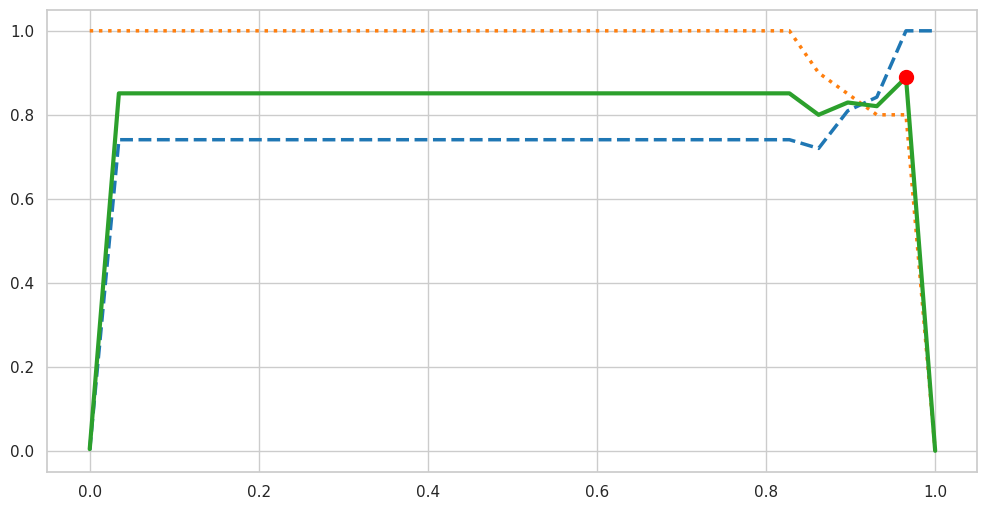

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot Precision, Recall, and F1 lines
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["precision"], label="Precision", color="#1f77b4", linewidth=2.5, linestyle="--")
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["recall"], label="Recall (Sensitivity)", color="#ff7f0e", linewidth=2.5, linestyle=":")
plt.plot(df_threshold_curve["threshold"], df_threshold_curve["f1_score"], label="F1-Score", color="#2ca02c", linewidth=3)

# Highlight the optimal F1 threshold
best_f1 = best_row["f1_score"]
best_thresh = best_row["threshold"]
plt.scatter(best_thresh, best_f1, color="red", s=100, zorder=5, label=f"Max F1 ({best_f1:.4f} @ {best_thresh:.2f})")
plt.axvline(x=best_thresh, color="red", linestyle="alpha", alpha=0.4, linewidth=1.5)

# Formatting text and layout
plt.title("Evaluation Metrics Across Probability Thresholds", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Match Probability Cutoff Threshold", fontsize=12)
plt.ylabel("Metric Score (0.0 to 1.0)", fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend(loc="lower left", frameon=True, fontsize=11)
plt.tight_layout()

# Render the final chart
plt.show()


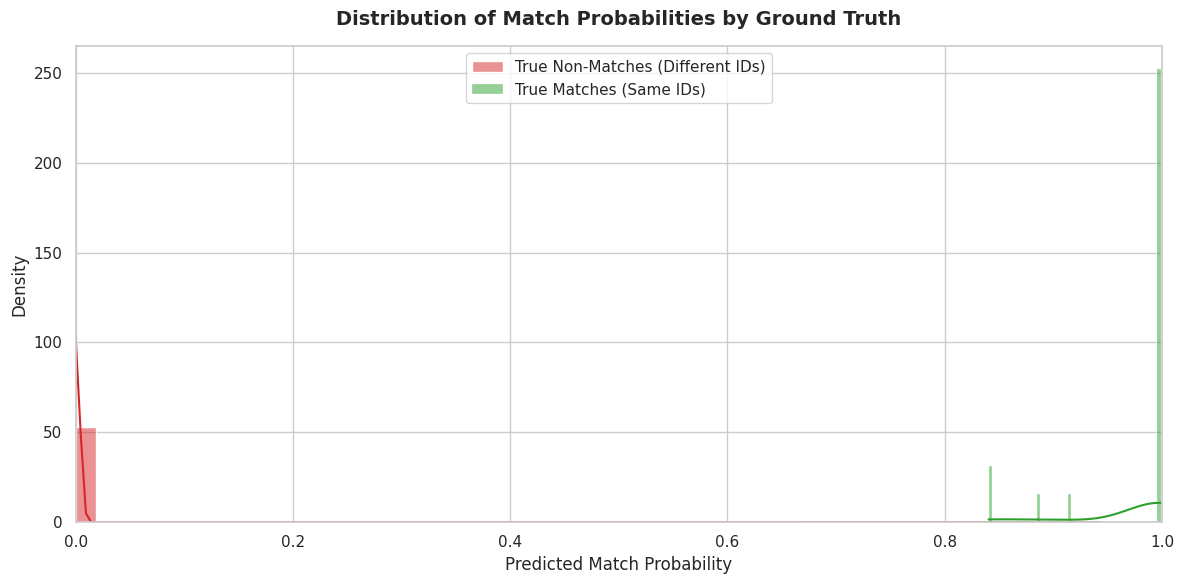

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the ground truth column is computed
pd_predict["is_true_match"] = (
    pd_predict["unique_id_l"] == pd_predict["unique_id_r"]
)

plt.figure(figsize=(12, 6))

# Plot distribution for True Non-Matches
sns.histplot(
    data=pd_predict[~pd_predict["is_true_match"]],
    x="match_probability",
    bins=50,
    kde=True,
    color="#d62728",
    label="True Non-Matches (Different IDs)",
    alpha=0.5,
    stat="density",
)

# Plot distribution for True Matches
sns.histplot(
    data=pd_predict[pd_predict["is_true_match"]],
    x="match_probability",
    bins=50,
    kde=True,
    color="#2ca02c",
    label="True Matches (Same IDs)",
    alpha=0.5,
    stat="density",
)

# Formatting layout
plt.title(
    "Distribution of Match Probabilities by Ground Truth",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Predicted Match Probability", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0.0, 1.0)
plt.legend(loc="upper center", frameon=True, fontsize=11)
plt.tight_layout()

plt.show()
